# Performance Analysis with Alphalens

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from collections import defaultdict
from time import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from alphalens.tears import (create_returns_tear_sheet,
                             create_summary_tear_sheet,
                             create_full_tear_sheet)

from alphalens.performance import mean_return_by_quantile
from alphalens.plotting    import plot_quantile_returns_bar
from alphalens.utils       import get_clean_factor_and_forward_returns, rate_of_return

In [3]:
sns.set_style('whitegrid')

In [4]:
np.random.seed(42)
idx = pd.IndexSlice

In [5]:
results_path = Path('C:/','data','results', 'asset_pricing')

print(results_path)
#f not results_path.exists():
#   results_path.mkdir(parents=True)

C:\data\results\asset_pricing


## Alphalens Analysis

### Load predictions

In [11]:
DATA_STORE = Path(results_path / 'data.h5')

In [12]:
predictions = pd.read_hdf(results_path / 'predictions_reloaded.h5', 'predictions')

In [13]:
factor = (predictions.mean(axis=1)
          .unstack('ticker')
          .resample('W-FRI', level='date')
          .last()
          .stack()
          .tz_localize('UTC', level='date')
          .sort_index())
tickers = factor.index.get_level_values('ticker').unique()

### Get trade prices

In [14]:
def get_trade_prices(tickers):
    prices = pd.read_hdf(DATA_STORE, 'stocks/prices/adjusted')
    prices.index.names = ['ticker', 'date']
    prices = prices.loc[idx[tickers, '2014':'2020'], 'open']
    return (prices
            .unstack('ticker')
            .sort_index()
            .shift(-1)
            .resample('W-FRI', level='date')
            .last()
            .tz_localize('UTC'))

In [15]:
trade_prices = get_trade_prices(tickers)

In [16]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 314 entries, 2014-01-03 00:00:00+00:00 to 2020-01-03 00:00:00+00:00
Freq: W-FRI
Columns: 3430 entries, A to ZYXI
dtypes: float64(3430)
memory usage: 8.2 MB


In [17]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 314 entries, 2014-01-03 00:00:00+00:00 to 2020-01-03 00:00:00+00:00
Freq: W-FRI
Columns: 3430 entries, A to ZYXI
dtypes: float64(3430)
memory usage: 8.2 MB


In [18]:
trade_prices.to_hdf('tmp.h5', 'trade_prices')

### Generate tearsheet input

In [19]:
factor_data = get_clean_factor_and_forward_returns(factor=factor,
                                                   prices=trade_prices,
                                                   quantiles=5,
                                                   periods=(5, 10, 21)).sort_index()
factor_data.info()

Dropped 18.5% entries from factor data: 18.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 726571 entries, (Timestamp('2015-01-09 00:00:00+0000', tz='UTC'), 'A') to (Timestamp('2019-08-09 00:00:00+0000', tz='UTC'), 'ZYXI')
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   5D               726571 non-null  float64
 1   10D              726571 non-null  float64
 2   21D              726571 non-null  float64
 3   factor           726571 non-null  float32
 4   factor_quantile  726571 non-null  int64  
dtypes: float32(1), float64(3), int64(1)
memory usage: 27.9+ MB


### Create Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-1.781871,0.083766,-0.152837,0.117055,145411,20.013323
2,-0.328258,0.152787,-0.047786,0.063096,145267,19.993504
3,-0.246721,0.221266,0.012578,0.053542,145259,19.992403
4,-0.174129,0.294571,0.077003,0.055444,145267,19.993504
5,-0.092778,0.954205,0.193172,0.099037,145367,20.007267


Returns Analysis


,5D,10D,21D
Ann. alpha,0.025,0.014,0.008
beta,0.041,0.026,0.019
Mean Period Wise Return Top Quantile (bps),13.060,9.714,8.781
Mean Period Wise Return Bottom Quantile (bps),-3.601,2.675,4.767
Mean Period Wise Spread (bps),16.661,6.917,3.828


Information Analysis


,5D,10D,21D
IC Mean,0.000,-0.002,-0.011
IC Std.,0.080,0.069,0.068
Risk-Adjusted IC,0.006,-0.033,-0.154
t-stat(IC),0.091,-0.514,-2.389
p-value(IC),0.928,0.607,0.018
IC Skew,-0.312,-0.023,-0.340
IC Kurtosis,-0.194,-0.263,1.327


Turnover Analysis


,5D,10D,21D
Quantile 1 Mean Turnover,0.575,0.651,0.744
Quantile 2 Mean Turnover,0.727,0.750,0.774
Quantile 3 Mean Turnover,0.746,0.770,0.787
Quantile 4 Mean Turnover,0.724,0.753,0.780
Quantile 5 Mean Turnover,0.530,0.596,0.693


,5D,10D,21D
Mean Factor Rank Autocorrelation,0.475,0.355,0.173


<Figure size 640x480 with 0 Axes>

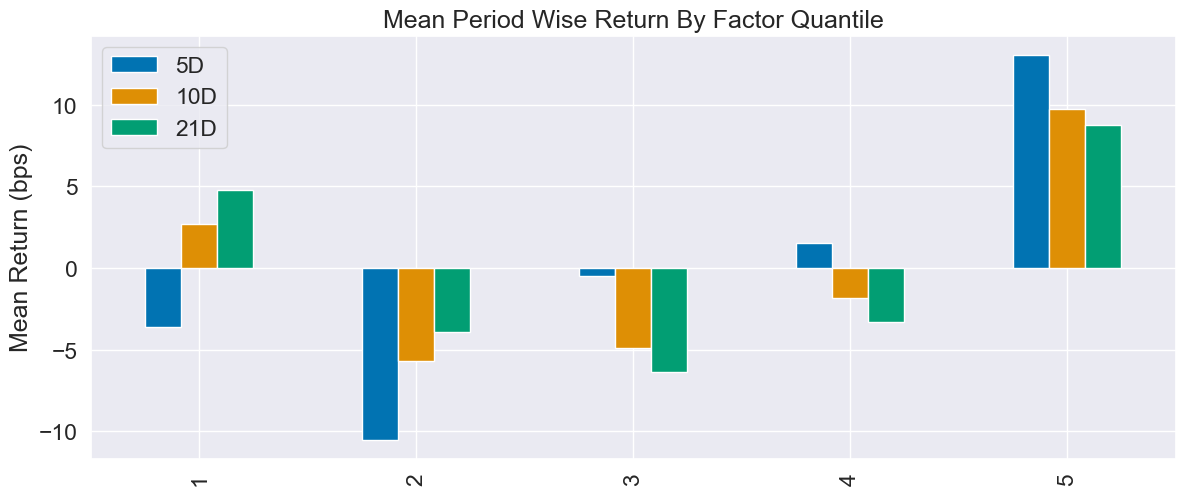

In [20]:
create_summary_tear_sheet(factor_data)

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-1.781871,0.083766,-0.152837,0.117055,145411,20.013323
2,-0.328258,0.152787,-0.047786,0.063096,145267,19.993504
3,-0.246721,0.221266,0.012578,0.053542,145259,19.992403
4,-0.174129,0.294571,0.077003,0.055444,145267,19.993504
5,-0.092778,0.954205,0.193172,0.099037,145367,20.007267


Returns Analysis


,5D,10D,21D
Ann. alpha,0.025,0.014,0.008
beta,0.041,0.026,0.019
Mean Period Wise Return Top Quantile (bps),13.060,9.714,8.781
Mean Period Wise Return Bottom Quantile (bps),-3.601,2.675,4.767
Mean Period Wise Spread (bps),16.661,6.917,3.828


<Figure size 640x480 with 0 Axes>

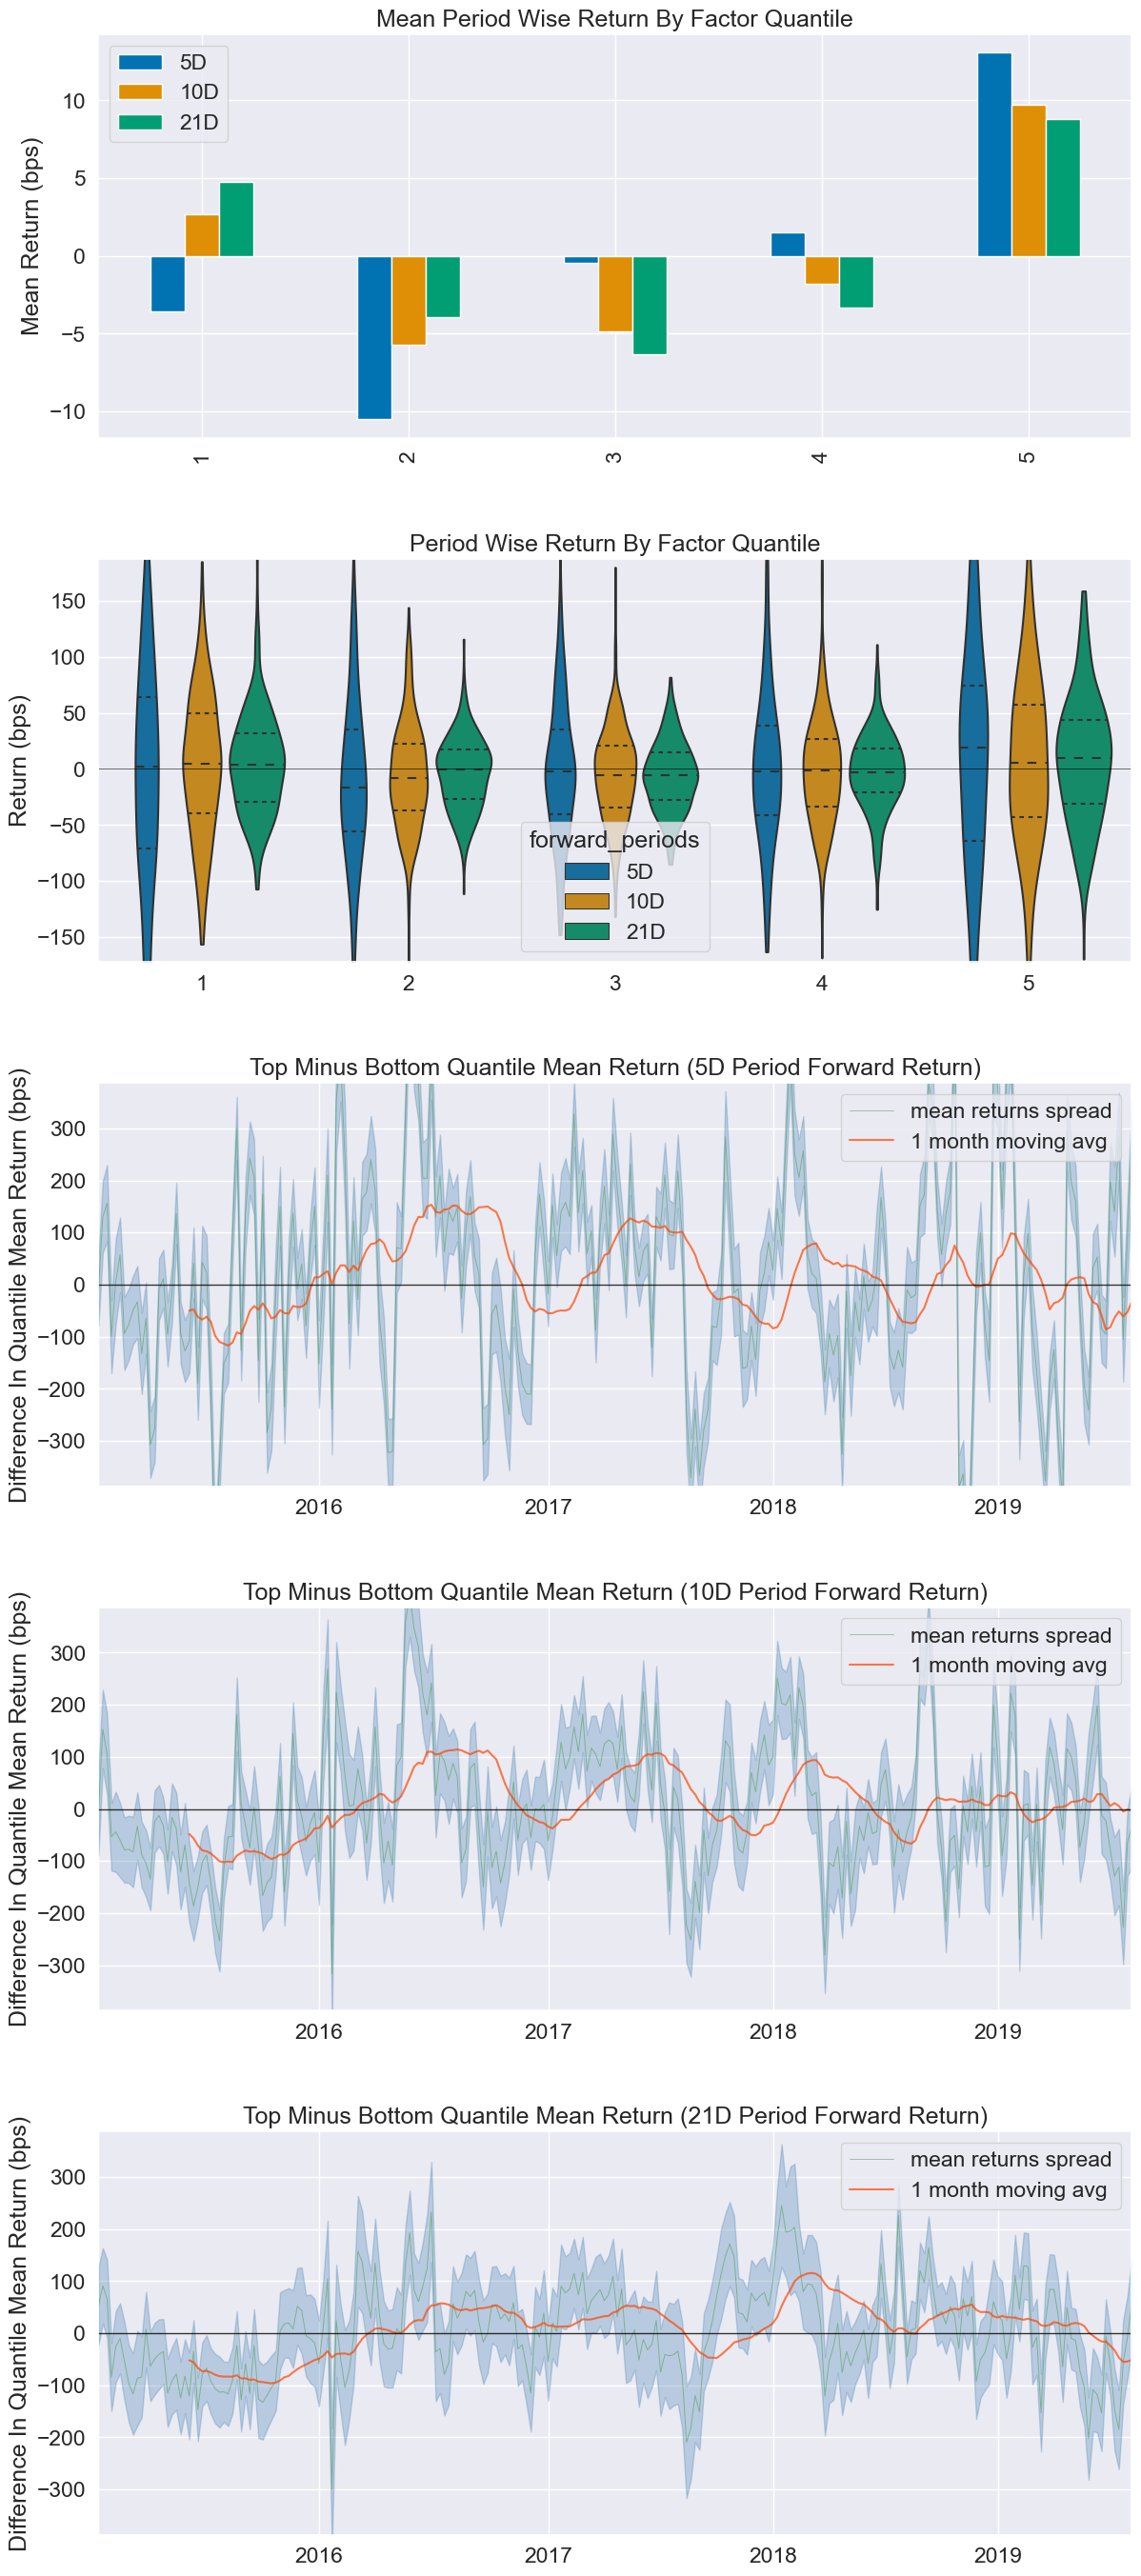

Information Analysis


,5D,10D,21D
IC Mean,0.000,-0.002,-0.011
IC Std.,0.080,0.069,0.068
Risk-Adjusted IC,0.006,-0.033,-0.154
t-stat(IC),0.091,-0.514,-2.389
p-value(IC),0.928,0.607,0.018
IC Skew,-0.312,-0.023,-0.340
IC Kurtosis,-0.194,-0.263,1.327


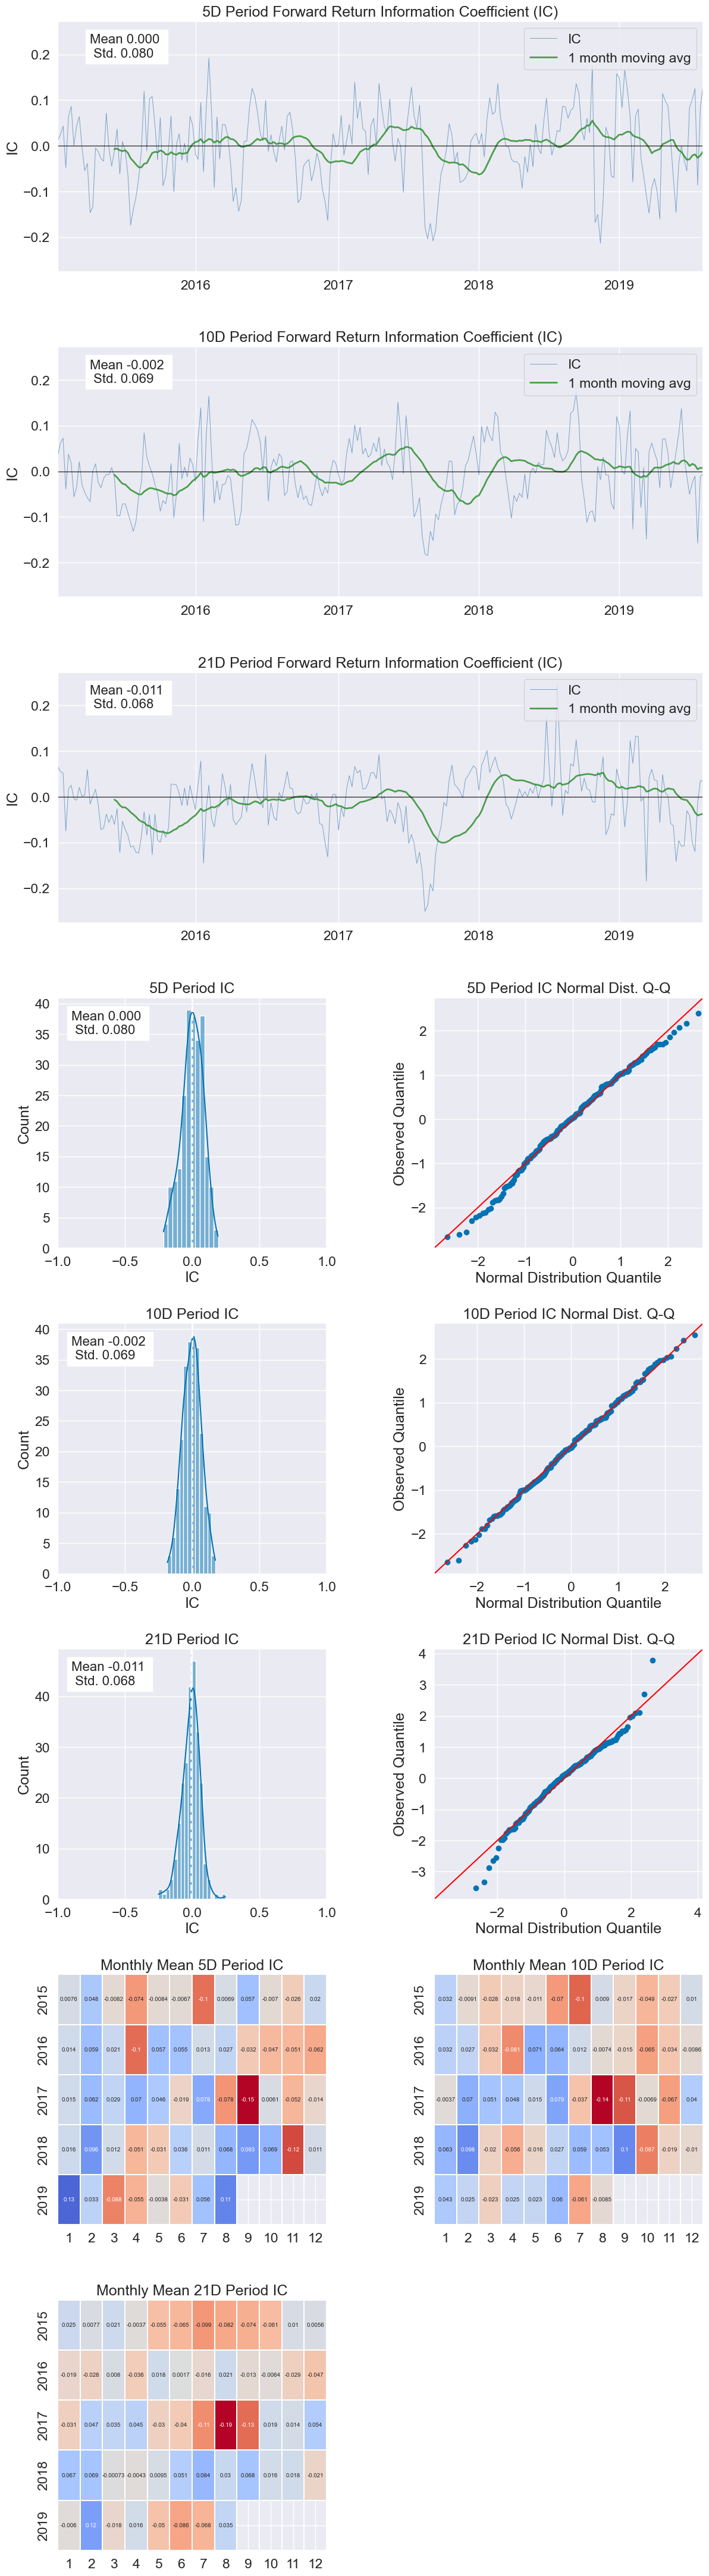

Turnover Analysis


,5D,10D,21D
Quantile 1 Mean Turnover,0.575,0.651,0.744
Quantile 2 Mean Turnover,0.727,0.750,0.774
Quantile 3 Mean Turnover,0.746,0.770,0.787
Quantile 4 Mean Turnover,0.724,0.753,0.780
Quantile 5 Mean Turnover,0.530,0.596,0.693


,5D,10D,21D
Mean Factor Rank Autocorrelation,0.475,0.355,0.173


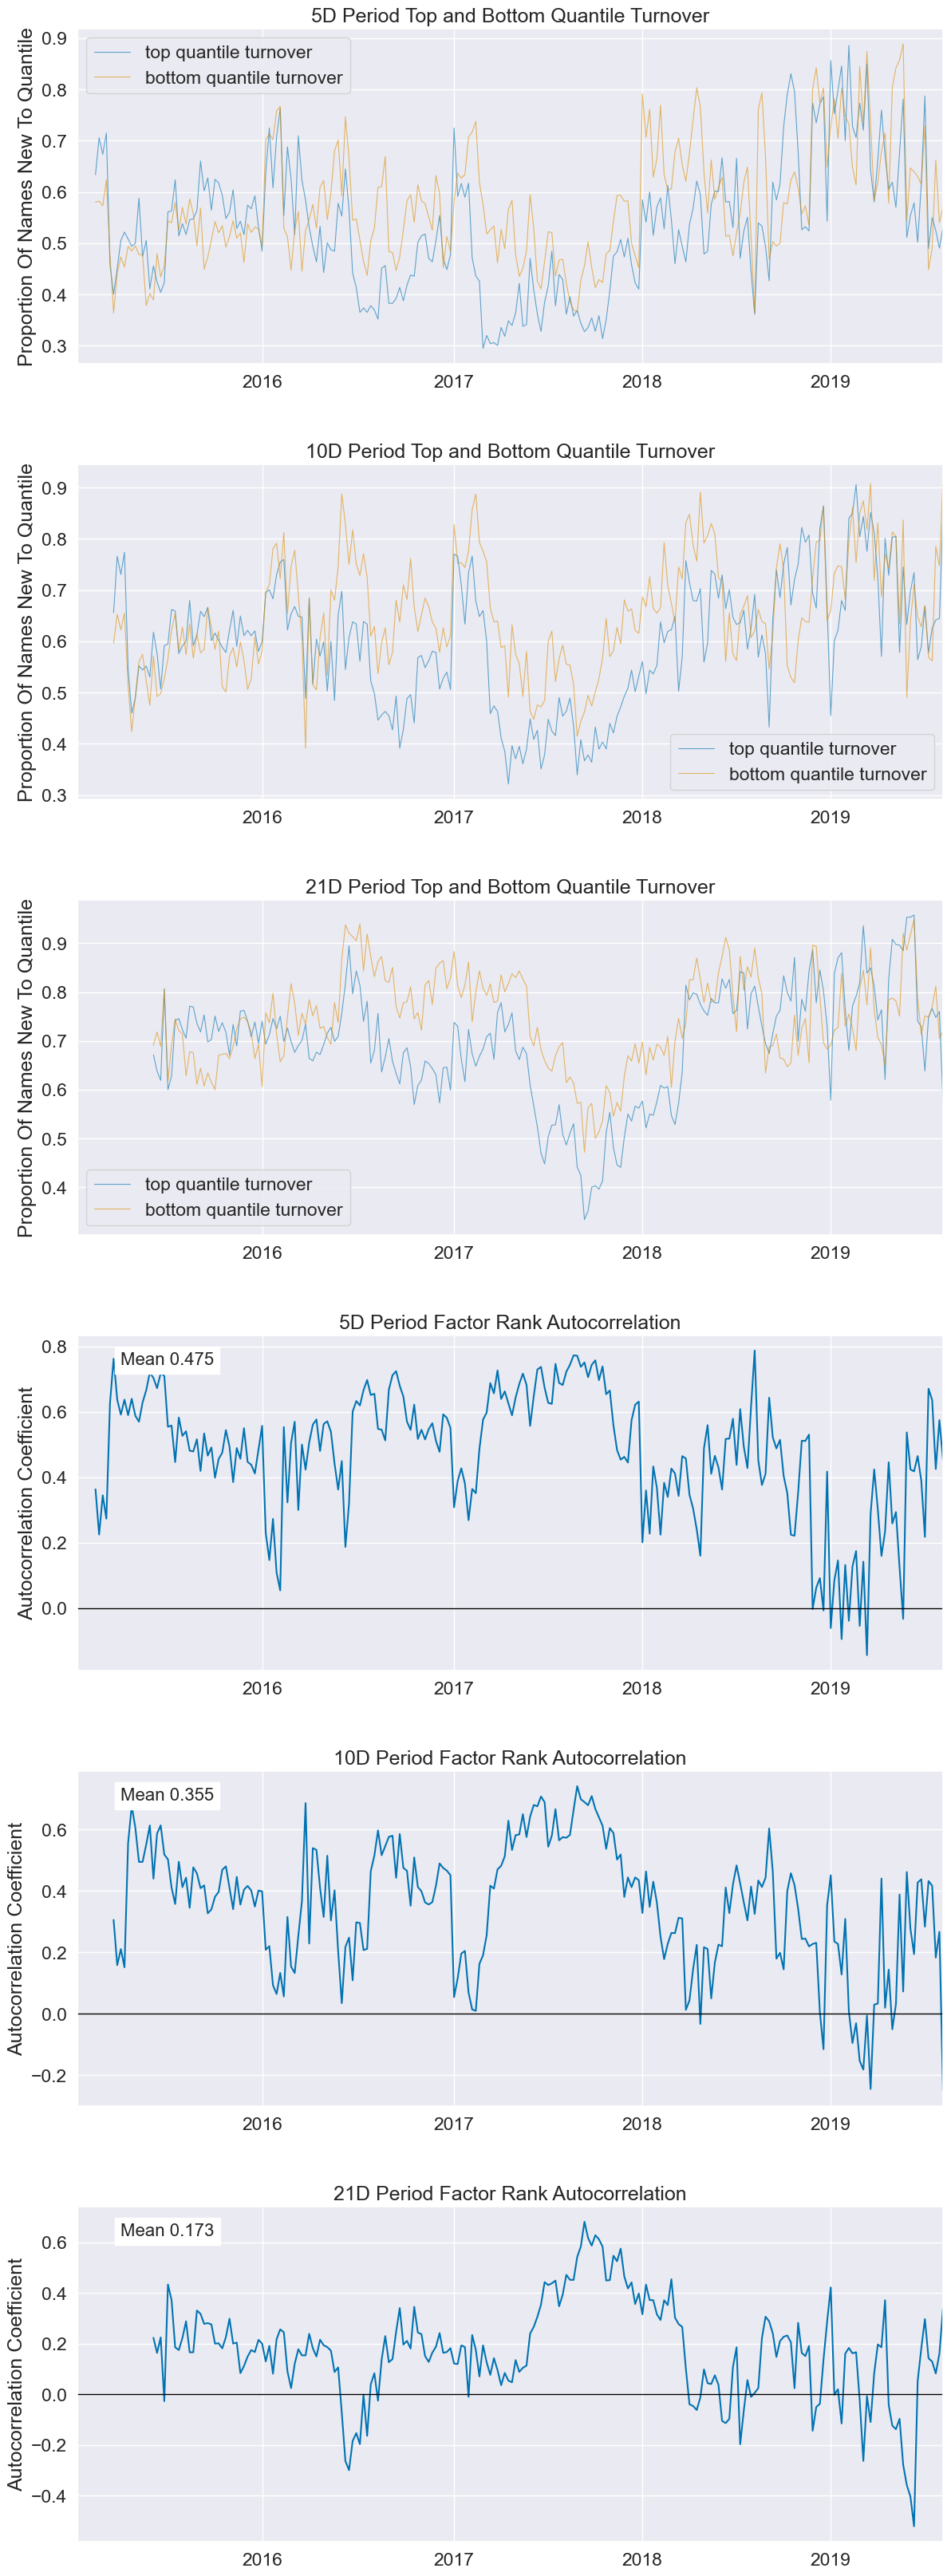

In [21]:
create_full_tear_sheet(factor_data)

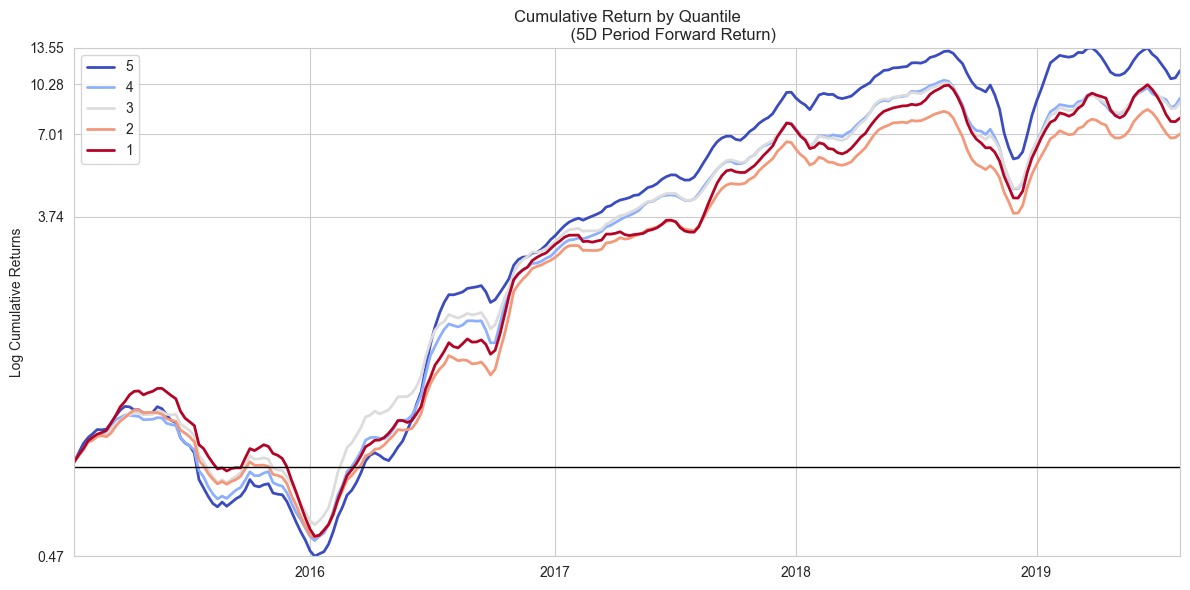

In [23]:
from alphalens.performance import mean_return_by_quantile
from alphalens.plotting import plot_cumulative_returns_by_quantile

# Calcola i rendimenti medi per quantile, per ogni data
mean_ret_by_q_daily, std_err = mean_return_by_quantile(
    factor_data, 
    by_date=True, 
    demeaned=False   # rendimenti non demeaned, come nella slide
)

# Grafico dei rendimenti cumulati – orizzonte 5D
fig, ax = plt.subplots(figsize=(12, 6))
plot_cumulative_returns_by_quantile(
    mean_ret_by_q_daily['5D'], 
    period='5D', 
    ax=ax
)
plt.tight_layout()
plt.show()

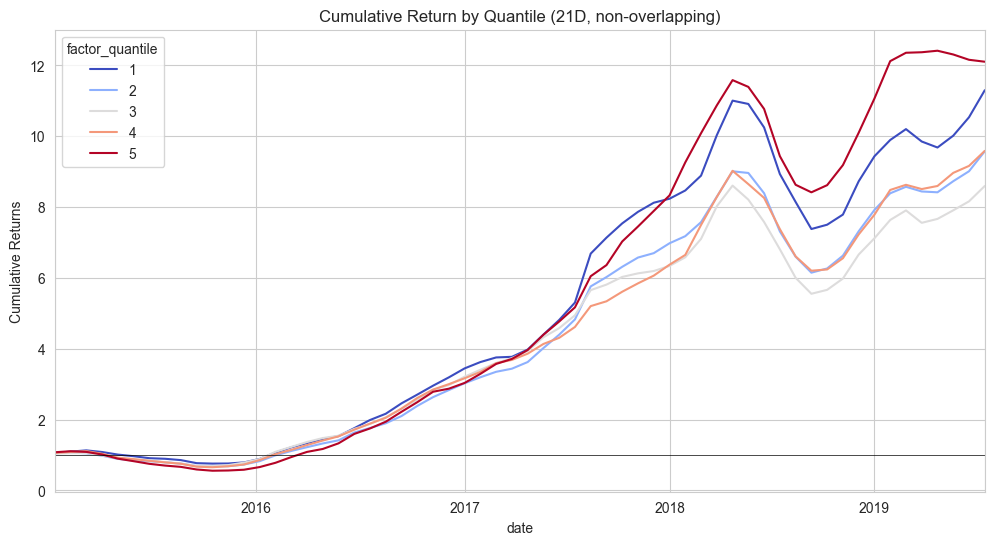

In [24]:
# Rendimenti medi per quantile per data
mean_ret_by_q, _ = mean_return_by_quantile(factor_data, by_date=True, demeaned=False)

# Prendi solo ogni 4a osservazione (~21 giorni) per eliminare la sovrapposizione
non_overlapping = mean_ret_by_q['21D'].unstack('factor_quantile').iloc[::4]

# Calcola il rendimento cumulato corretto
cum_ret = (1 + non_overlapping).cumprod()
cum_ret.plot(figsize=(12, 6), cmap='coolwarm')
plt.title('Cumulative Return by Quantile (21D, non-overlapping)')
plt.ylabel('Cumulative Returns')
plt.axhline(1.0, color='black', linewidth=0.5)
plt.show()